In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16


In [3]:
train_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
test_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test"

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 70295 files belonging to 38 classes.


I0000 00:00:1786107848.831585     651 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786107848.837009     651 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.


In [5]:

CLASS_NAMES = train_ds.class_names

NUM_CLASSES = len(CLASS_NAMES)

In [6]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

In [7]:
inputs = keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

model = keras.Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_efficientnet.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2
)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10


2026-08-07 13:05:09.683485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:05:09.824100: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:05:10.153510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:05:10.296099: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:05:11.094972: E external/local_xla/xla/stream_

4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8256 - loss: 0.7529

2026-08-07 13:06:51.745625: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:06:51.882162: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:06:52.198406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:06:52.340281: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:06:53.128650: E external/local_xla/xla/stream_

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8256 - loss: 0.7528

2026-08-07 13:07:32.028051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:07:32.163983: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:07:32.474940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:07:32.615615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:07:33.377071: E external/local_xla/xla/stream_

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 165s 32ms/step - accuracy: 0.9056 - loss: 0.3811 - val_accuracy: 0.9610 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 2/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 109s 25ms/step - accuracy: 0.9558 - loss: 0.1461 - val_accuracy: 0.9721 - val_loss: 0.0915 - learning_rate: 0.0010
Epoch 3/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 107s 24ms/step - accuracy: 0.9618 - loss: 0.1203 - val_accuracy: 0.9756 - val_loss: 0.0792 - learning_rate: 0.0010
Epoch 4/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 107s 24ms/step - accuracy: 0.9652 - loss: 0.1064 - val_accuracy: 0.9784 - val_loss: 0.0692 - learning_rate: 0.0010
Epoch 5/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 107s 24ms/step - accuracy: 0.9662 - loss: 0.0991 - val_accuracy: 0.9795 - val_loss: 0.0659 - learning_rate: 0.0010
Epoch 6/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 110s 25ms/step - accuracy: 0.9682 - loss: 0.0951 - val_accuracy: 0.9812 - val_loss: 0.0598 - learning_rate: 0.0010
Epoch 7/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 107s 24ms/step - accuracy: 

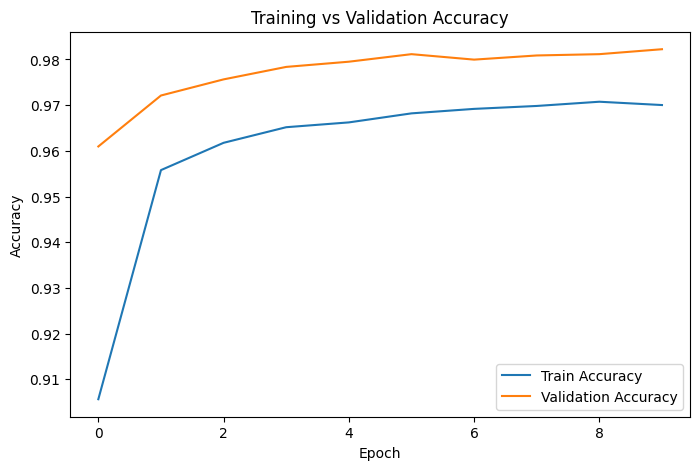

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

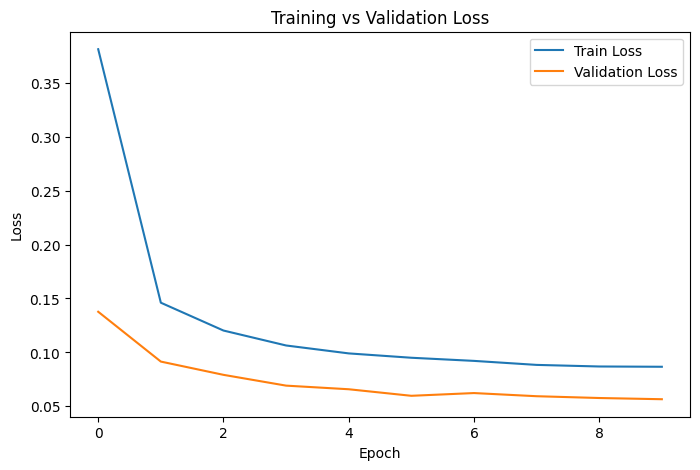

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [13]:
model.save("/kaggle/working/plant_disease_efficientnet.keras")

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

In [15]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [18]:
base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(300,300,3)
)

base_model.trainable = False

In [19]:
inputs = keras.Input(shape=(300,300,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

In [20]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_efficientnetb3.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

In [22]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10


2026-08-07 13:28:25.763234: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:28:25.908868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:28:26.280845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:28:26.428368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:28:27.240879: E external/local_xla/xla/stream_

4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8061 - loss: 0.6915

2026-08-07 13:33:21.879361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:33:22.018250: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:33:22.351199: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:33:22.498717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:33:23.290121: E external/local_xla/xla/stream_

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8061 - loss: 0.6915

2026-08-07 13:35:00.529521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:35:00.666702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:35:00.991643: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:35:01.140737: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 13:35:01.916019: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.96233, saving model to best_efficientnetb3.keras

Epoch 1: finished saving model to best_efficientnetb3.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 431s 88ms/step - accuracy: 0.8790 - loss: 0.4087 - val_accuracy: 0.9623 - val_loss: 0.1173 - learning_rate: 0.0010
Epoch 2/10
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9238 - loss: 0.2580
Epoch 2: val_accuracy improved from 0.96233 to 0.97177, saving model to best_efficientnetb3.keras

Epoch 2: finished saving model to best_efficientnetb3.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 339s 77ms/step - accuracy: 0.9261 - loss: 0.2591 - val_accuracy: 0.9718 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 3/10
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9310 - loss: 0.2527
Epoch 3: val_accuracy improved from 0.97177 to 0.97570, saving model to best_efficientnetb3.keras

Epoch 3: finished saving model to best_efficientnetb3.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 337s 77ms/step - accurac

In [23]:
model.save("plant_disease_efficientnetb3.keras")